# 81 - Milestone Project: CIFAR-10 Autoencoder

**Section:** CNN Milestone Projects | **Prereqs:** `CNN Milestone Projects/CIFAR_10.ipynb` | **Next:** `CNN Milestone Projects/Psychometric_functions_in_CNNs.ipynb`

The same data, no labels: compress each 3x32x32 image to a `4*chan_num x 4 x 4`
feature map and rebuild it. Self-supervised - the input is the target.

**A fully convolutional autoencoder.** There is no flatten and no `Linear` layer
anywhere. The latent code is a *spatial map*, not a vector, which preserves where
things are and produces far better reconstructions than a flattened bottleneck at
the same parameter count. Every strong image autoencoder is built this way.

**Reading the reconstructions.** Expect the right colours and coarse layout with
soft, blurry detail. That blur is inherent to MSE: when the model is unsure of an
edge's exact position, the loss-minimising answer is to average over the
possibilities, and the average of several sharp edges is a blurry one. Sharper
output needs a different objective - a perceptual loss, or an adversarial one,
which is what `GANs/` is about.

**What it is for.** Reconstruction itself is rarely the goal. The encoder is:
`Transfer Learning/Pretraining_with_AutoEncoders.ipynb` uses one as a pretrained
feature extractor, and the same structure underlies denoising, anomaly detection
and compression.

**The optional L1 penalty on the latent** (`l1_lambda`, off by default) pushes the
code towards sparsity - most entries zero, so each image is described by a few
active features. That is a *sparse* autoencoder.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from torchsummary import summary
from torchvision.datasets import CIFAR10

from sklearn.model_selection import train_test_split

In [2]:
# CIFAR-10 again. The labels are loaded but never used - this is unsupervised.
train = CIFAR10(root = '/', train=True, download=True)
test = CIFAR10(root='/', train=False, download=True)

100%|██████████| 170M/170M [00:06<00:00, 26.4MB/s]


In [3]:
train_data = train.data
train_label = train.targets

test_data = test.data
test_label = test.targets

In [4]:
categories = train.classes

In [5]:
categories

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [6]:
# Same preprocessing as the classifier: permute to (N,C,H,W) and scale to [0,1].
device = ('cuda' if torch.cuda.is_available() else 'cpu')

train_data, val_data , train_label , val_label = train_test_split(train_data, train_label, train_size=0.80)

train_dataset = TensorDataset(torch.tensor(train_data, dtype=torch.float,device=device).permute(0, 3, 1, 2) / 255., torch.tensor(train_label, dtype=torch.long,device=device))
val_dataset = TensorDataset(torch.tensor(val_data, dtype=torch.float,device=device).permute(0, 3, 1, 2) / 255., torch.tensor(val_label, dtype=torch.long,device=device))

test_dataset = TensorDataset(torch.tensor(test_data, dtype=torch.float,device=device).permute(0, 3, 1, 2) / 255., torch.tensor(test_label, dtype=torch.long,device=device))

In [7]:
val_dataset.tensors[0].shape ,  device

(torch.Size([10000, 3, 32, 32]), 'cuda')

In [8]:
# DataLoaders

bs = 256

train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=val_dataset.tensors[0].shape[0])
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

## AE Defination

In [9]:
# The autoencoder.
# Encoder: 3x32x32 -> 4*chan_num x 4x4, via three [Conv-BN-LeakyReLU-AvgPool]
# blocks.
# Decoder: three ConvTranspose2d(kernel=2, stride=2) layers, each exactly
# doubling the spatial size, mirroring the encoder's pooling.
# kernel_size=2 with stride=2 divides evenly, which avoids the checkerboard
# artifacts transposed convolution produces when they do not.
#
# Note there is NO flatten and no Linear layer: the latent is a spatial map,
# not a vector. That keeps positional information and reconstructs far better
# than a flattened bottleneck of the same size.
#
# Sigmoid on the output matches the [0,1] range of the scaled input.
# forward returns BOTH the reconstruction and the latent - the latent is the
# part you actually reuse later.
class Autoencoder(nn.Module):
    def __init__(self, chan_num=32):
        super().__init__()

        # ---- Encoder (no flatten, no linear) ----
        self.encoder = nn.Sequential(
            # Block 1: 3x32x32 -> chan_num x 32x32 -> 16x16
            nn.Conv2d(3, chan_num, kernel_size=3, padding=1),
            nn.BatchNorm2d(chan_num),
            nn.LeakyReLU(inplace=True),
            nn.AvgPool2d(2, 2),

            # Block 2: chan_num x 16x16 -> 2*chan_num x 16x16 -> 8x8
            nn.Conv2d(chan_num, 2*chan_num, kernel_size=3, padding=1),
            nn.BatchNorm2d(2*chan_num),
            nn.LeakyReLU(inplace=True),
            nn.AvgPool2d(2, 2),

            # Block 3: 2*chan_num x 8x8 -> 4*chan_num x 8x8 -> 4x4
            nn.Conv2d(2*chan_num, 4*chan_num, kernel_size=3, padding=1),
            nn.BatchNorm2d(4*chan_num),
            nn.LeakyReLU(inplace=True),
            nn.AvgPool2d(2, 2),
        )
        self.latent_channels = 4 * chan_num   # latent shape: [B, 4*chan_num, 4, 4]

        # ---- Decoder (mirror of encoder, no linear layers) ----
        self.decoder = nn.Sequential(
            # Upsample 4x4 -> 8x8
            nn.ConvTranspose2d(4*chan_num, 2*chan_num, kernel_size=2, stride=2),
            nn.BatchNorm2d(2*chan_num),
            nn.LeakyReLU(inplace=True),

            # Upsample 8x8 -> 16x16
            nn.ConvTranspose2d(2*chan_num, chan_num, kernel_size=2, stride=2),
            nn.BatchNorm2d(chan_num),
            nn.LeakyReLU(inplace=True),

            # Upsample 16x16 -> 32x32
            nn.ConvTranspose2d(chan_num, 3, kernel_size=2, stride=2),
            nn.Sigmoid()   # output in [0,1] for normalized images
        )

    def forward(self, x):
        latent_map = self.encoder(x)         # [B, 4*chan_num, 4, 4]
        reconstruction = self.decoder(latent_map)  # [B, 3, 32, 32]
        return reconstruction, latent_map


In [10]:
test_model = Autoencoder(64).to(device)

In [11]:
# torchsummary - verify the decoder returns to exactly (3,32,32).
summary(test_model, input_size=(3,32,32), batch_size=128)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [128, 64, 32, 32]           1,792
       BatchNorm2d-2          [128, 64, 32, 32]             128
         LeakyReLU-3          [128, 64, 32, 32]               0
         AvgPool2d-4          [128, 64, 16, 16]               0
            Conv2d-5         [128, 128, 16, 16]          73,856
       BatchNorm2d-6         [128, 128, 16, 16]             256
         LeakyReLU-7         [128, 128, 16, 16]               0
         AvgPool2d-8           [128, 128, 8, 8]               0
            Conv2d-9           [128, 256, 8, 8]         295,168
      BatchNorm2d-10           [128, 256, 8, 8]             512
        LeakyReLU-11           [128, 256, 8, 8]               0
        AvgPool2d-12           [128, 256, 4, 4]               0
  ConvTranspose2d-13           [128, 128, 8, 8]         131,200
      BatchNorm2d-14           [128, 12

In [12]:
# Training with MSELoss(recon, x) - target is the input.
# The optional l1_lambda penalises the latent's magnitude, pushing it towards
# sparsity (most entries zero). That is a sparse autoencoder; it is off by
# default here.
def train_autoencoder(chan_num, epochs=50, lr=1e-3, l1_lambda=0):
    model = Autoencoder(chan_num).to(device)
    recon_loss_fn = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=5e-4,
        betas=(0.9, 0.999)
    )

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for x, _ in train_loader:
            x = x.to(device)
            recon, latent = model(x)
            loss = recon_loss_fn(recon, x)

            if l1_lambda > 0:
                l1_norm = torch.abs(latent).mean()
                loss = loss + l1_lambda * l1_norm

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        avg_train_loss = np.mean(batch_losses)
        train_losses.append(avg_train_loss)

        model.eval()
        with torch.no_grad():
            X_val, _ = next(iter(val_loader))
            X_val = X_val.to(device)
            recon_val, _ = model(X_val)
            val_loss = recon_loss_fn(recon_val, X_val).item()
        val_losses.append(val_loss)

        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f'Epoch {epoch:3d} | Train Loss: {avg_train_loss:.6f} | Val Loss: {val_loss:.6f}')

    return model, train_losses, val_losses


In [21]:
# Train with chan_num=512, giving a 2048x4x4 latent.
model, train_losses, val_losses = train_autoencoder(512)

Epoch   0 | Train Loss: 0.027701 | Val Loss: 0.061690
Epoch  10 | Train Loss: 0.008487 | Val Loss: 0.027033
Epoch  20 | Train Loss: 0.004397 | Val Loss: 0.007434
Epoch  30 | Train Loss: 0.004176 | Val Loss: 0.005537
Epoch  40 | Train Loss: 0.004104 | Val Loss: 0.006611
Epoch  49 | Train Loss: 0.004083 | Val Loss: 0.007111


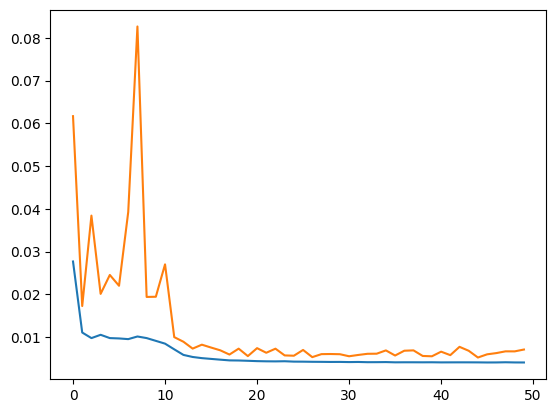

In [22]:
# Train and validation reconstruction loss.
plt.plot(train_losses)
plt.plot(val_losses);


In [23]:
# Test-set reconstruction loss - the honest number.
with torch.no_grad():
    X, _ = next(iter(test_loader))
    X = X.to(device)
    recon, _ = model(X)
    test_loss = nn.MSELoss()(recon, X).item()

In [24]:
test_loss

0.00708194263279438

In [25]:
# A helper to display originals above reconstructions.
# .permute(1,2,0) converts back to (H,W,C); .clamp(0,1) avoids matplotlib
# warnings about out-of-range values.
def show_reconstructions(model, test_loader, n=10):
    model.eval()
    X, _ = next(iter(test_loader))
    X = X[:n].to(device)

    with torch.no_grad():
        recon, _ = model(X)

    X = X.cpu()
    recon = recon.cpu()

    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    for i in range(n):
        # Original
        axes[0, i].imshow(X[i].permute(1, 2, 0).clamp(0, 1))
        axes[0, i].set_title('Original', fontsize=9)
        axes[0, i].axis('off')

        # Reconstructed
        axes[1, i].imshow(recon[i].permute(1, 2, 0).clamp(0, 1))
        axes[1, i].set_title('Reconstructed', fontsize=9)
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()


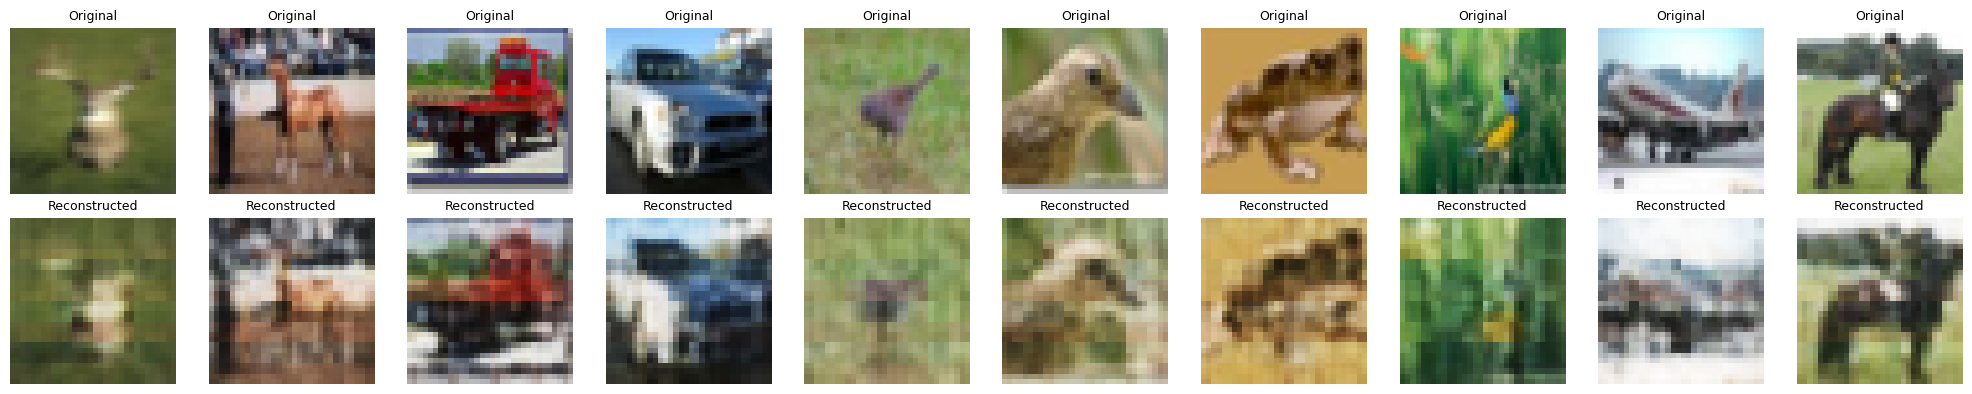

In [26]:
# Originals vs reconstructions.
# Expect correct colours and coarse structure with soft detail. That blur is MSE
# doing exactly what it is asked to: when uncertain about an edge, averaging is
# the loss-minimising answer. Sharper output needs a perceptual or adversarial
# loss - which is what GANs/ introduces.
show_reconstructions(model,test_loader)